In [1]:
# Requires seaborn in addition to requirements.txt packages
import math
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import evaluation

from evaluation import load_results_dataframe

# --- Plot style configuration ---
plt.style.use("default")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.size"] = 14
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.5
plt.rcParams["figure.figsize"] = [12, 12]
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
def check_missing_seeds(df, name=""):
    print(f"\n=== Missing seeds report: {name} ===")
    df['algorithm'] = df['algorithm'].apply(
        lambda x: x.split("/")[-1].upper()
                   .replace("UNIFIED_", "")
                   .replace("AUGMENTED_METHODS/", "")
                   .replace("UREBRAC", "UBRAC")
    )
    expected_seeds = set(df["seed"].unique())
    print(f"Expected seeds (union across all runs): {sorted(expected_seeds)}")
    
    # Print per-algorithm seed counts to spot imbalances
    for algo, group in df.groupby("algorithm"):
        present = sorted(group["seed"].unique())
        print(f"  {algo}: {len(present)} seeds {present}")
    print()

    all_combos = df.groupby(["algorithm", "dataset_name"])
    
    any_missing = False
    for (algo, dataset), group in all_combos:
        present = set(group["seed"].unique())
        missing = expected_seeds - present
        if missing:
            print(f"  {algo} | {dataset}: missing seeds {sorted(missing)}")
            any_missing = True
    
    if not any_missing:
        print("  No missing seeds.")
        
def drop_duplicate_seeds(df, keep="last"):
    return df.sort_values("final_scores_mean").drop_duplicates(
        subset=["algorithm", "dataset_name", "seed"], keep=keep
    )

df_full   = drop_duplicate_seeds(load_results_dataframe("rollouts/results_full_eval"))
df_rebrac = drop_duplicate_seeds(load_results_dataframe("rollouts/rebrac"))
#df_pbrl   = drop_duplicate_seeds(load_results_dataframe("rollouts/second_pbrl_sweep"))
df_sparse = drop_duplicate_seeds(load_results_dataframe("rollouts/sparse_eval"))
df_aug    = drop_duplicate_seeds(load_results_dataframe("rollouts/aug_vs_ensembles"))


check_missing_seeds(df_full,   "full eval")
check_missing_seeds(df_rebrac, "rebrac")
#check_missing_seeds(df_pbrl,   "pbrl")
check_missing_seeds(df_sparse, "sparse eval")
check_missing_seeds(df_aug,    "aug vs ensembles")


=== Missing seeds report: full eval ===
Expected seeds (union across all runs): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  AWAC: 20 seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  BC: 20 seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  EDAC: 20 seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  IQL: 20 seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  MSG: 20 seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  PBRL: 20 seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  REBRAC: 20 seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  SACN: 20 seeds [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

  No missing seeds.

=== Missing seeds report: rebrac ===
Expected seeds (union across all runs): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 

In [7]:
# --- Define bandit evaluation and plotting ---
def plot_trial(final_scores, num_subsample=8, **kwargs):
    # Run multiple bandit trials and compute confidence intervals
    runs = np.stack(final_scores.values)[:20]
    res = evaluation.bootstrap_bandit_trials(
        runs, num_subsample=num_subsample, n_bootstraps=2000, num_repeats=500
    )

    # Plotting
    line = plt.semilogx(res["pulls"], res["estimated_bests_mean"], **kwargs)
    plt.fill_between(
        res["pulls"],
        res["estimated_bests_ci_low"],
        res["estimated_bests_ci_high"],
        alpha=0.3,
        color=line[0].get_color(),
    )

Running bandit evaluation... Done.
Running bandit evaluation... Done.
Running bandit evaluation... Done.
Running bandit evaluation... Done.


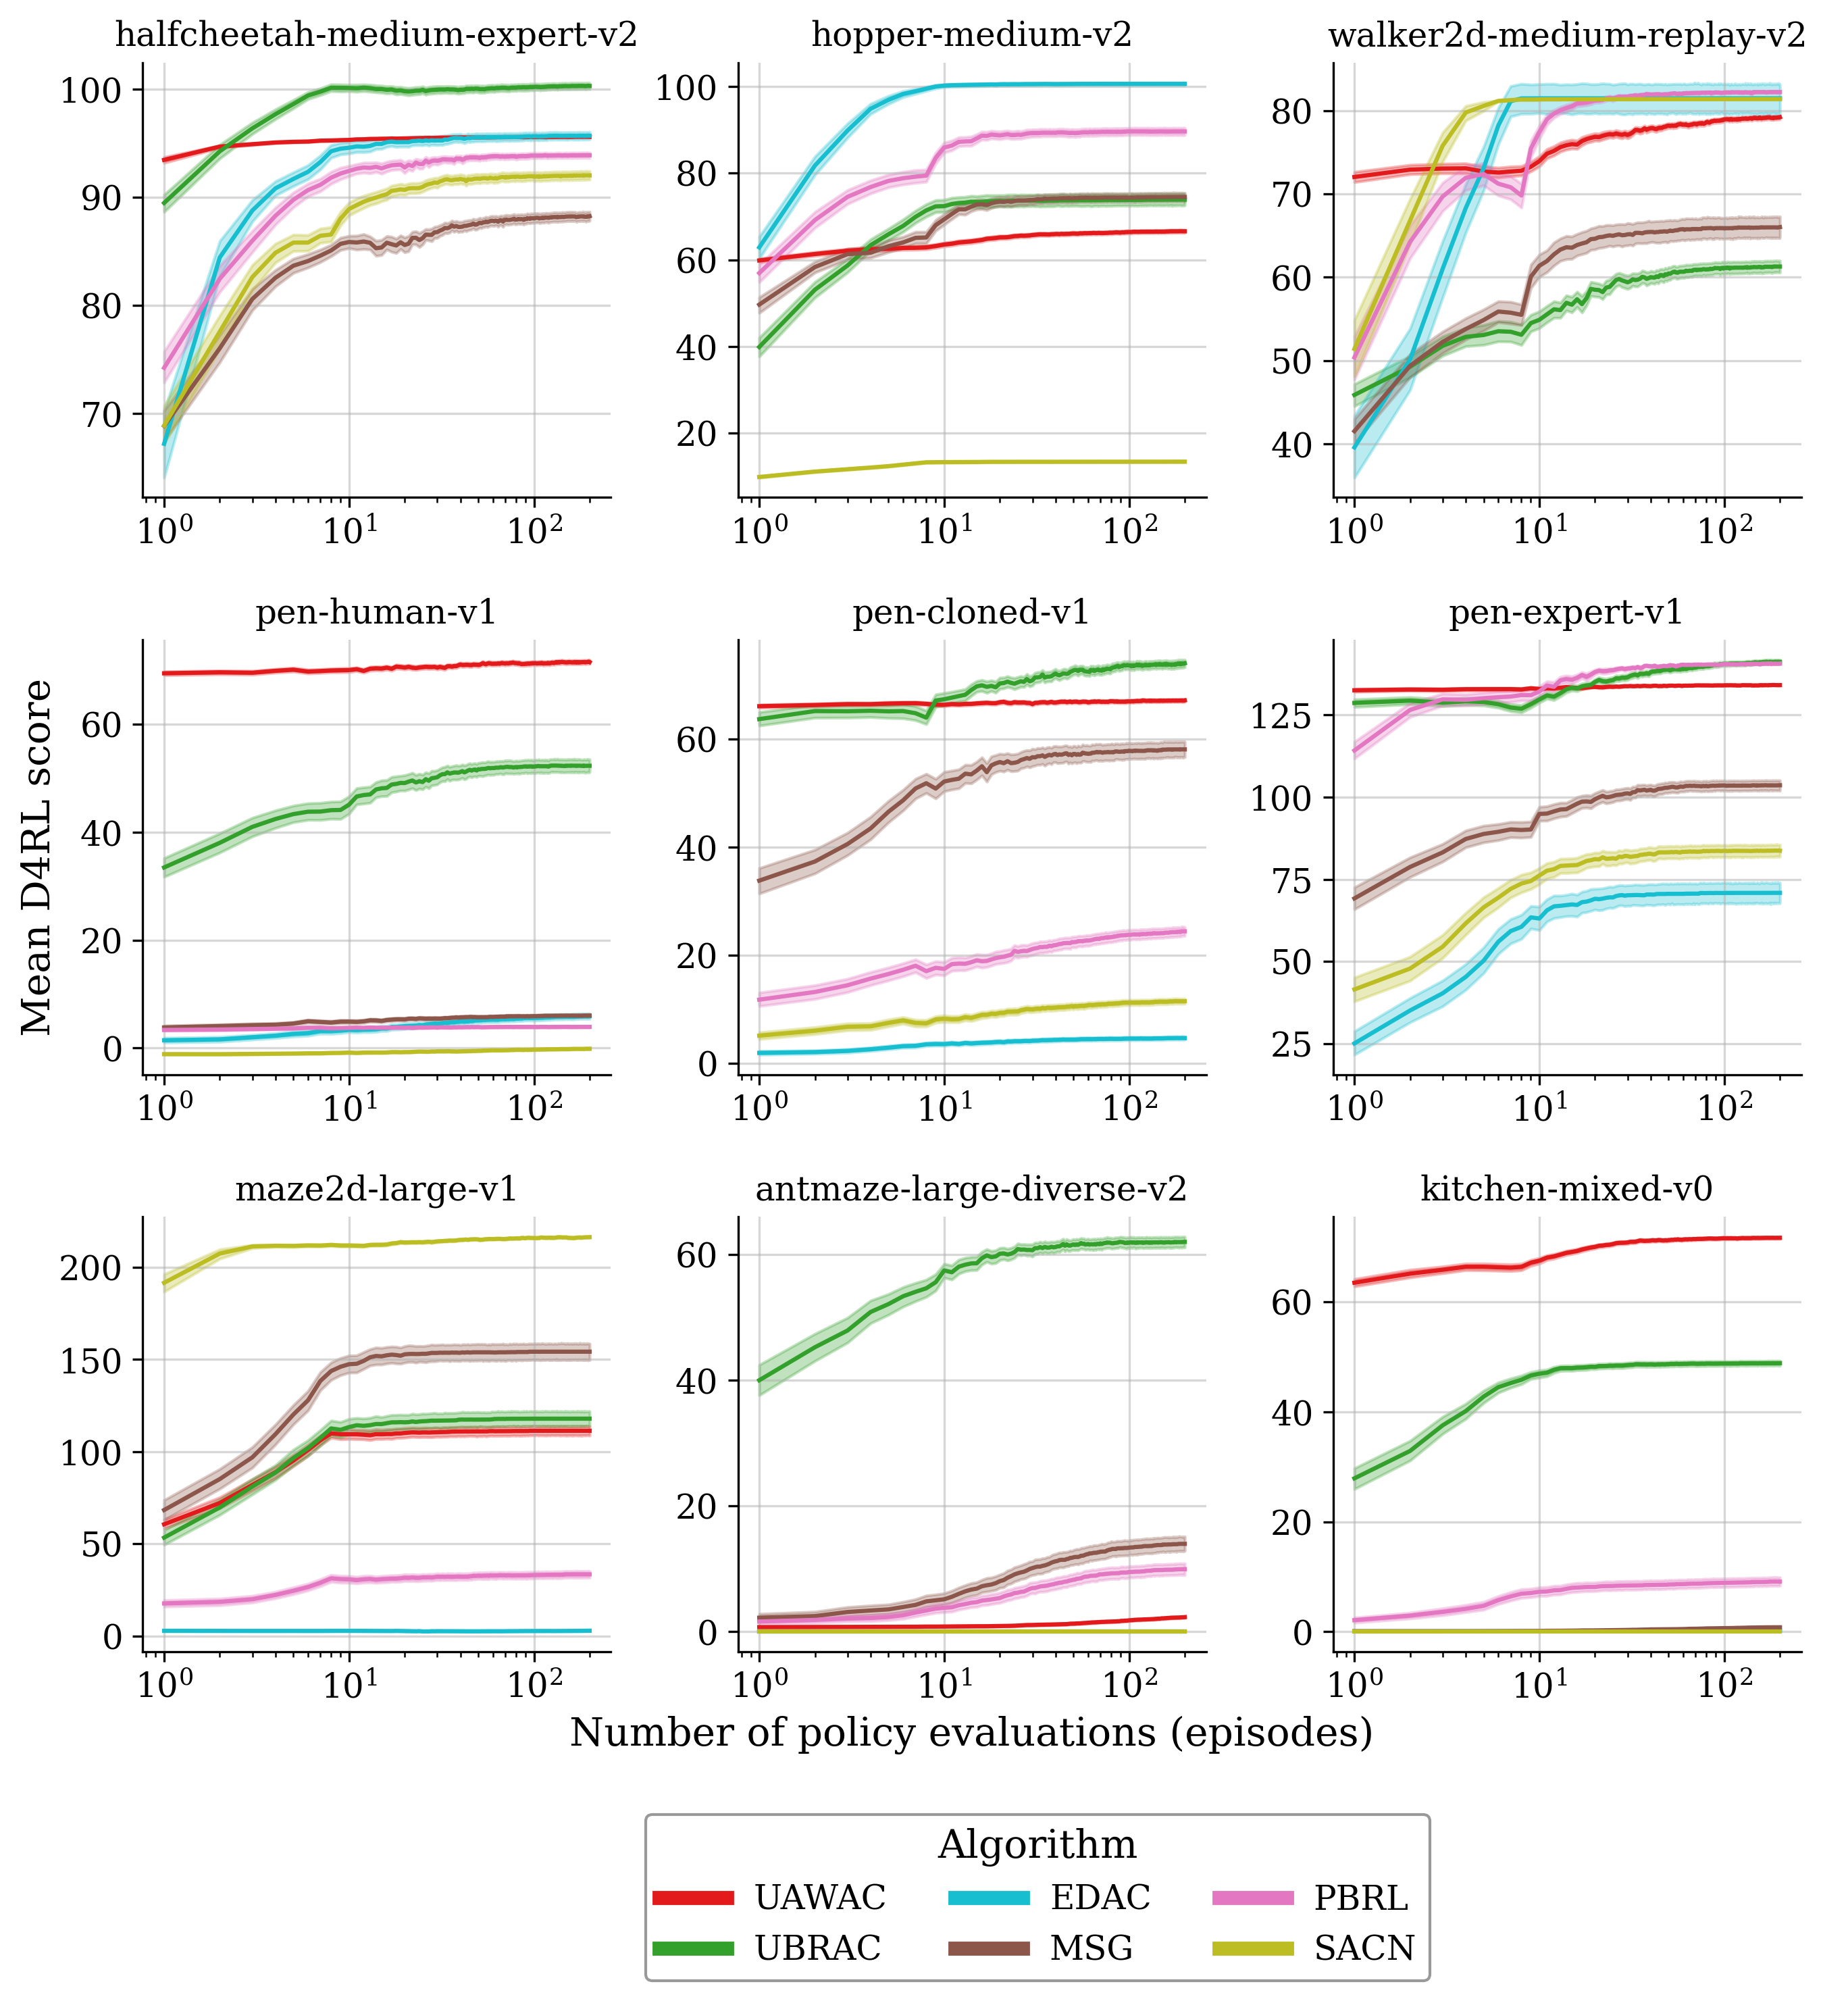

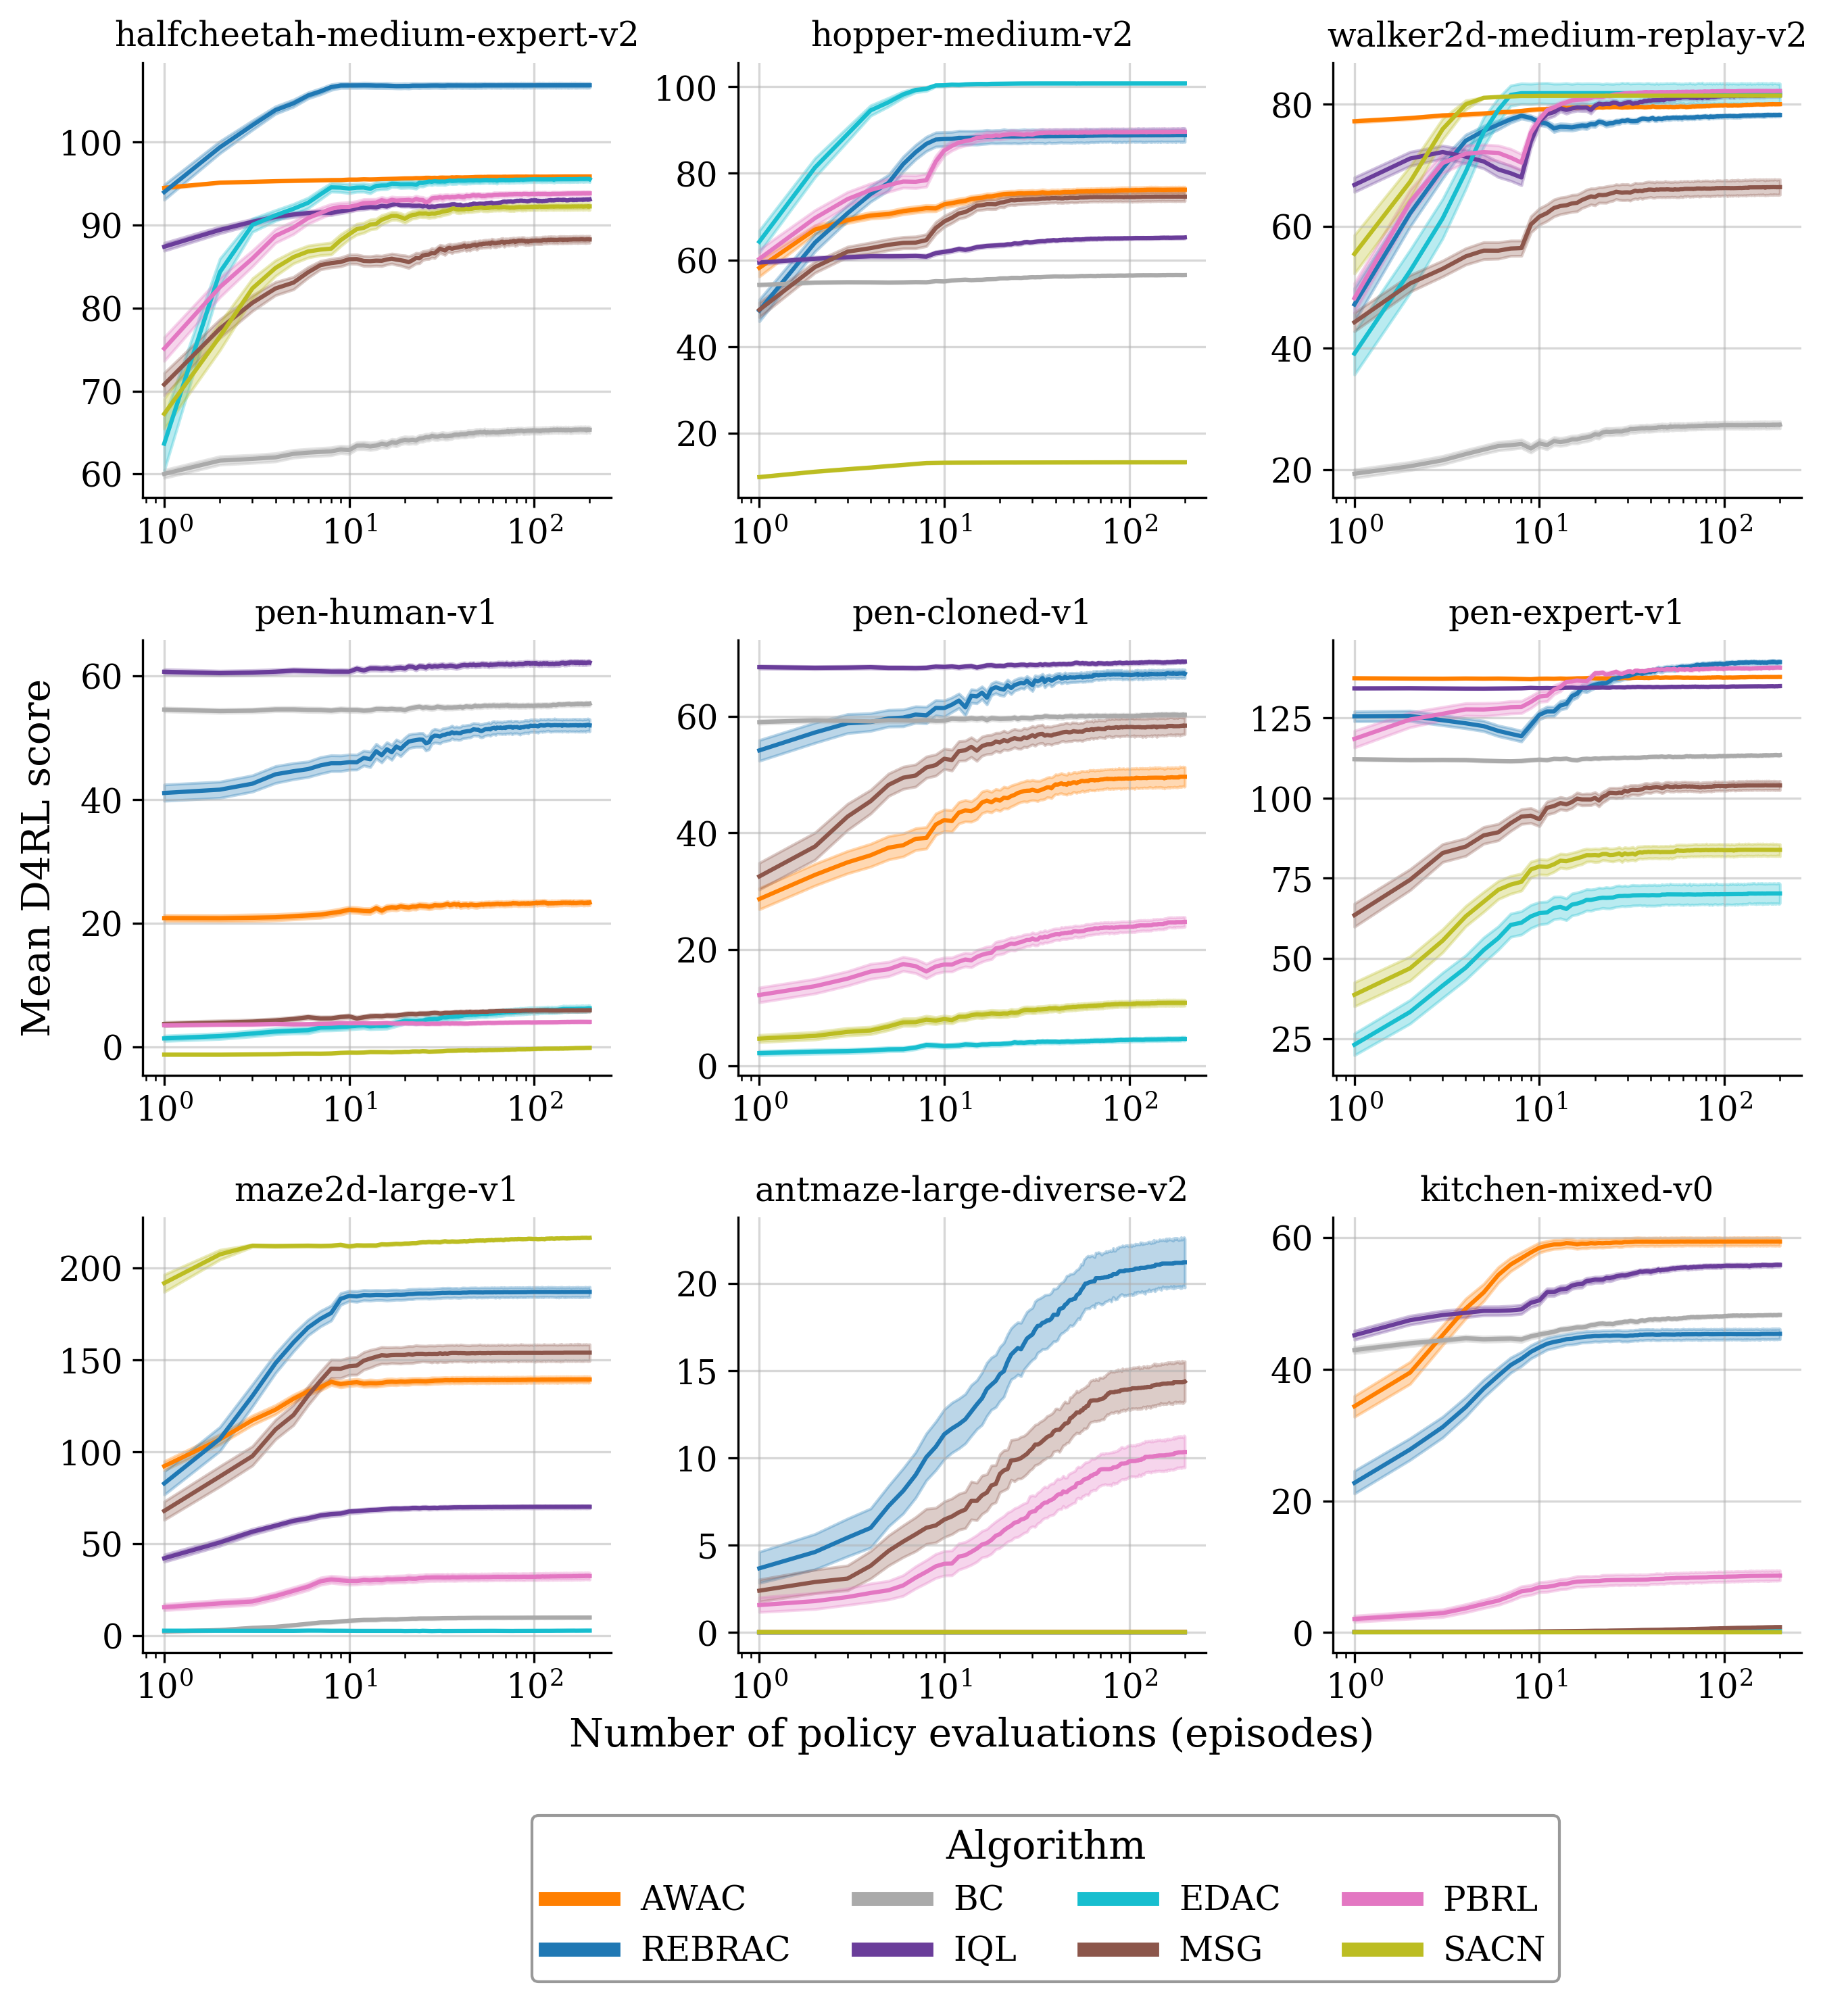

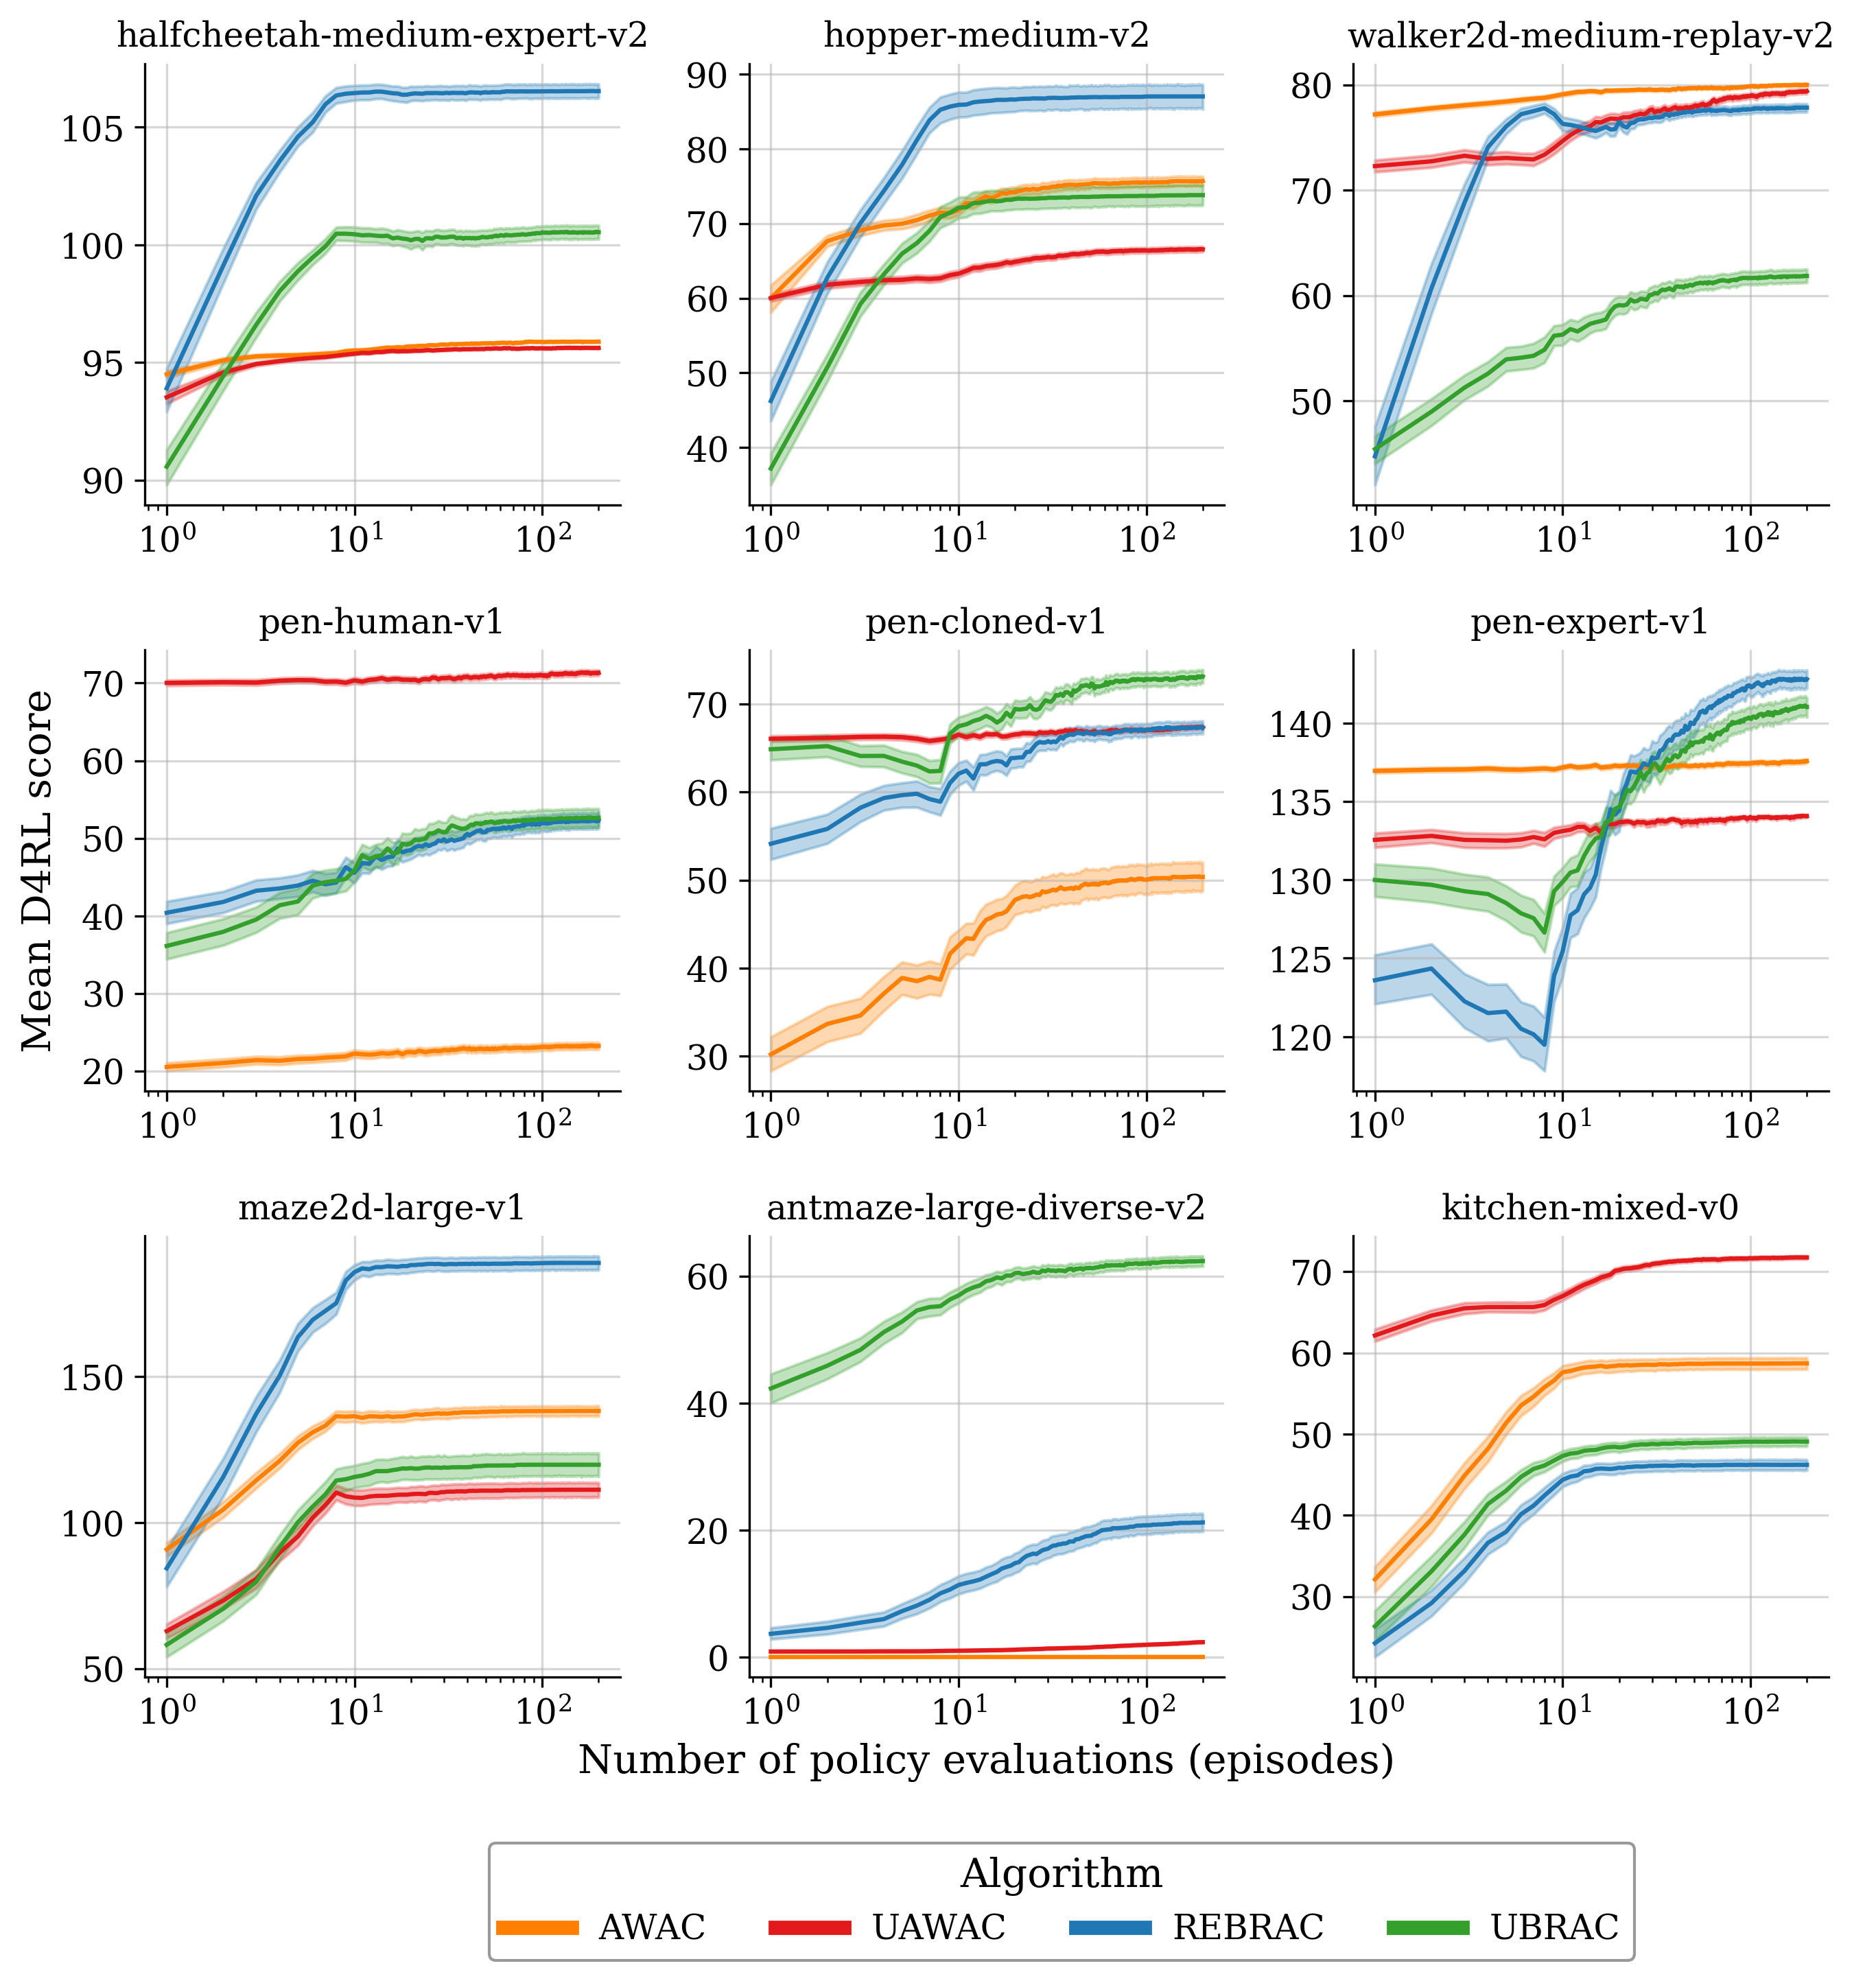

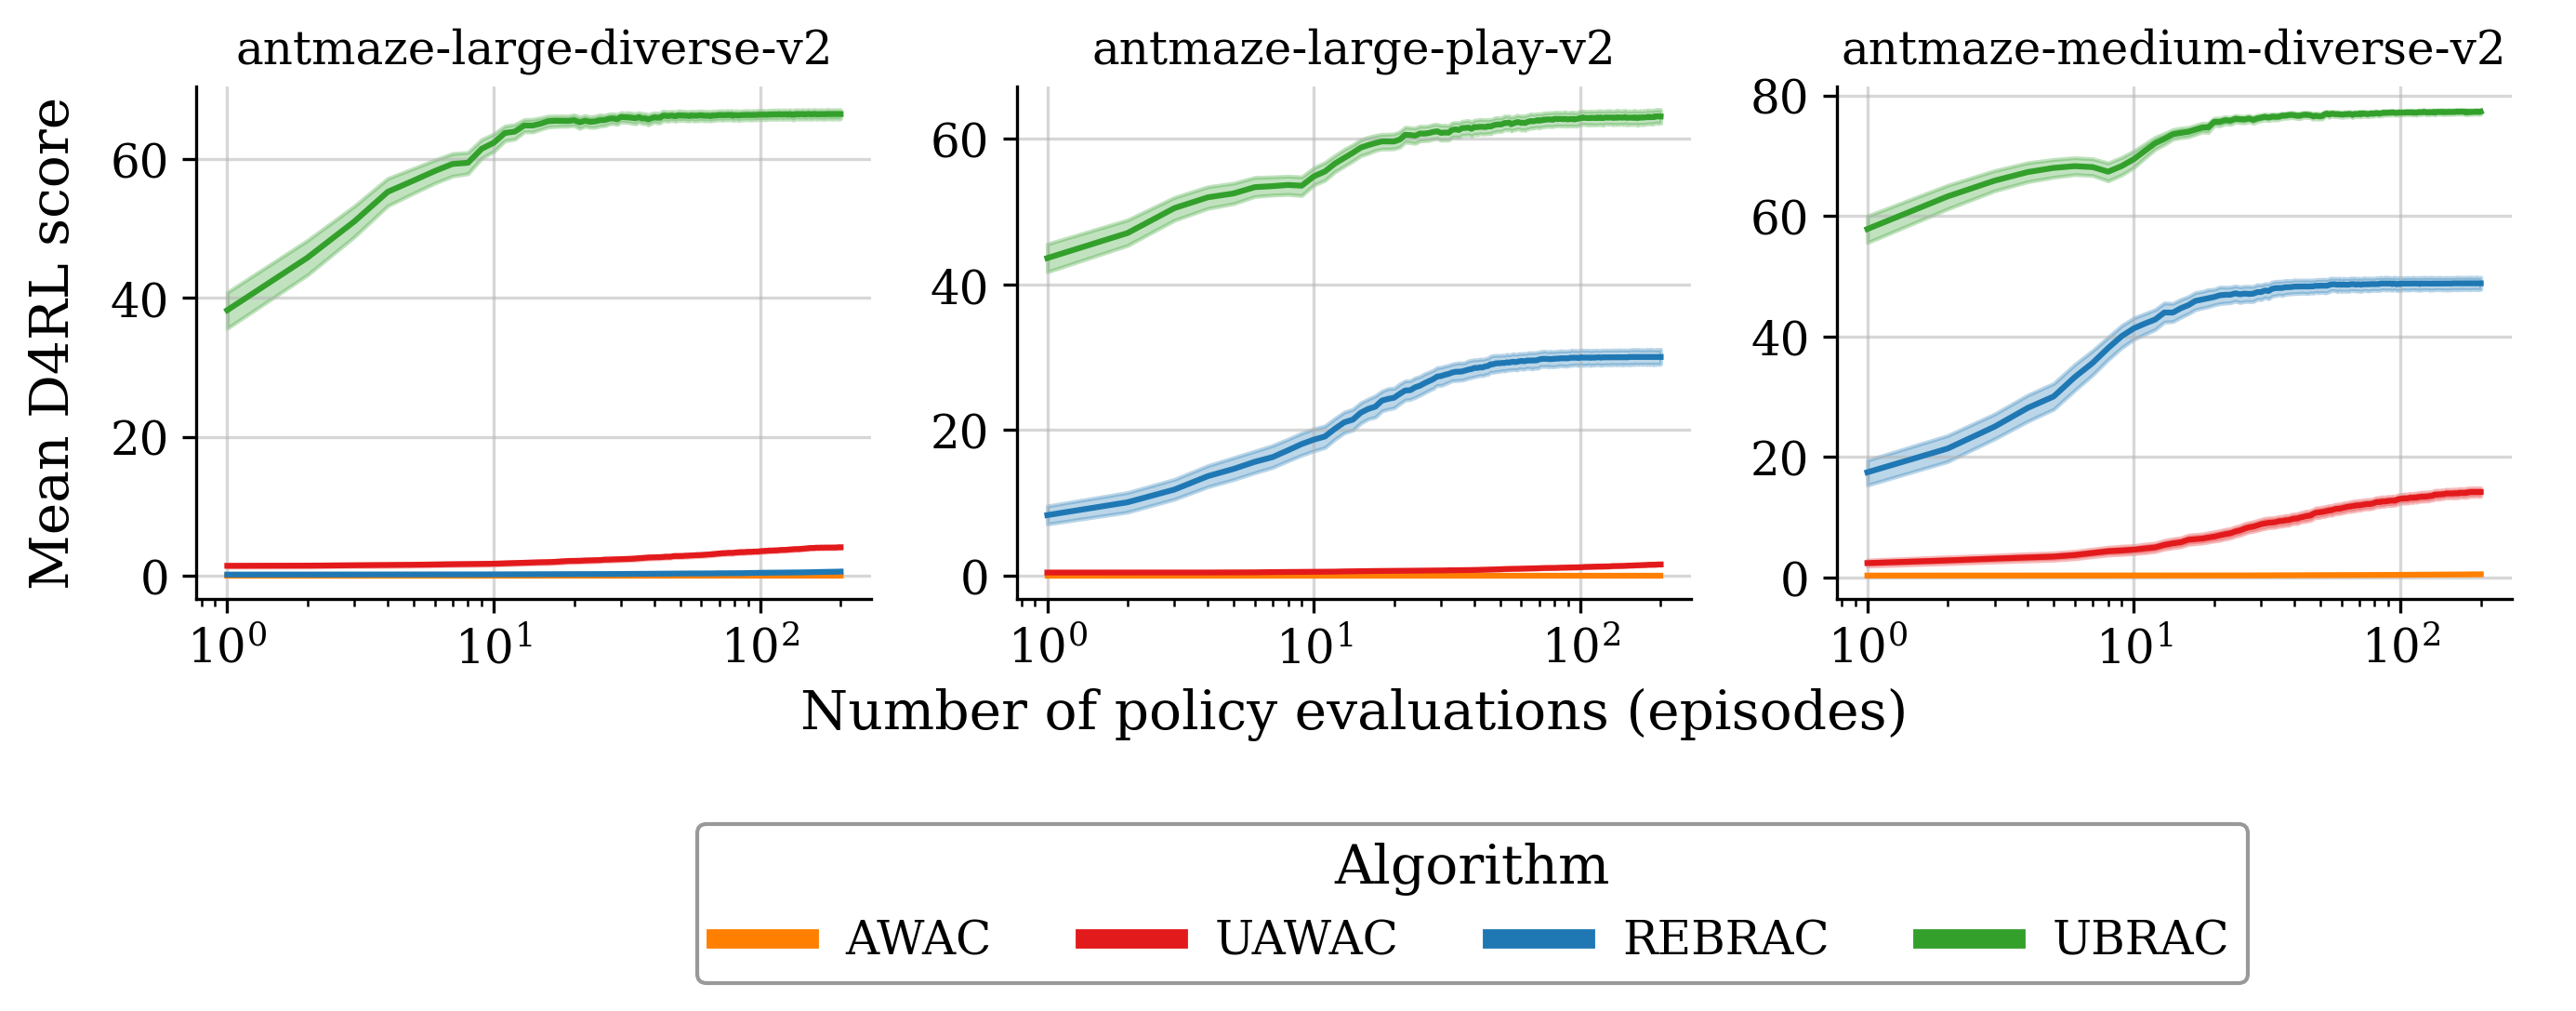

In [9]:
FIXED_COLORS = {
    # AWAC family: warm red/orange
    "AWAC":    "#ff7f00",  # vivid orange
    "UAWAC":   "#e31a1c",  # vivid red
    # REBRAC family: cool blue/teal
    "REBRAC":  "#1f78b4",  # strong blue
    "UBRAC":   "#33a02c",  # strong green
    # Others
    "BC":      "#aaaaaa",  # soft gray
    "IQL":     "#6a3d9a",  # purple
    "EDAC":    "#17becf",  # teal
    "MSG":     "#8c564b",  # brown
    "PBRL":    "#e377c2",  # soft pink
    "SACN":    "#bcbd22",  # olive
}
DATASET_ORDER = [
    # MuJoCo
    "halfcheetah-medium-expert-v2",
    "hopper-medium-v2", 
    "walker2d-medium-replay-v2",
    # Pen
    "pen-human-v1",
    "pen-cloned-v1",
    "pen-expert-v1",
    # Mazes
    "maze2d-large-v1",
    "antmaze-large-diverse-v2",
    # Kitchen
    "kitchen-mixed-v0",
]

ALGO_ORDER = ["AWAC", "UAWAC", "REBRAC", "UBRAC", "BC", "IQL", "EDAC", "MSG", "PBRL", "SACN"]

for i, plot_df in enumerate([df_aug, df_full, df_rebrac, df_sparse]):
    plot_df = plot_df.copy()  # avoid mutating original
    
    plot_df['algorithm'] = plot_df['algorithm'].apply(
        lambda x: x.split("/")[-1].upper()
                   .replace("UNIFIED_", "")
                   .replace("AUGMENTED_METHODS/", "")
                   .replace("UREBRAC", "UBRAC")
    )

    present_algos = plot_df["algorithm"].unique()
    ordered_algos = [a for a in ALGO_ORDER if a in present_algos]
    other_algos = [a for a in present_algos if a not in ALGO_ORDER]
    ordered_algos = ordered_algos + other_algos

    present_datasets = plot_df["dataset"].unique()
    ordered_datasets = [d for d in DATASET_ORDER if d in present_datasets]
    other_datasets = [d for d in present_datasets if d not in DATASET_ORDER]
    ordered_datasets = ordered_datasets + other_datasets

    plot_df['algorithm'] = pd.Categorical(plot_df['algorithm'], categories=ordered_algos, ordered=True)
    plot_df['dataset'] = pd.Categorical(plot_df['dataset'], categories=ordered_datasets, ordered=True)
    plot_df = plot_df.sort_values(['dataset', 'algorithm'])

    ALGORITHM_COLOR_DICT = {algo: FIXED_COLORS.get(algo, "#333333") for algo in ordered_algos}

    plot_df['algorithm'] = pd.Categorical(plot_df['algorithm'], categories=ordered_algos, ordered=True)
    plot_df = plot_df.sort_values('algorithm')
    plot_df["dataset"] = pd.Categorical(plot_df["dataset"])

    num_algorithms = len(ordered_algos)
    g = sns.FacetGrid(
        plot_df,
        col="dataset",
        hue="algorithm",
        hue_order=ordered_algos,
        col_wrap=3,
        sharex=False,
        sharey=False,
        palette=ALGORITHM_COLOR_DICT,
    )
    print("Running bandit evaluation... ", end='')
    g.map(plot_trial, "final_scores")
    print("Done.")

    for ax in g.axes.flat:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(ax.get_title().replace("dataset = ", ""))

    fig = plt.gcf()
    big_ax = fig.add_subplot(111, frameon=False)
    big_ax.tick_params(labelcolor="none", top=False, bottom=False, left=False, right=False)
    big_ax.grid(False)
    plt.xlabel("Number of policy evaluations (episodes)")
    plt.ylabel("Mean D4RL score")

    g.add_legend(title="Algorithm")
    leg = g._legend
    for line, text in zip(leg.get_lines(), leg.get_texts()):
        line.set_linewidth(5.0)

    #ncol = 4 if num_algorithms == 8 else num_algorithms
    ncol = num_algorithms // 2
    if i == 0:
        ncol == 3
    if i >= 2:
        ncol = 4
    sns.move_legend(
        g,
        "upper center",
        bbox_to_anchor=(0.5, 0.0),
        ncol=ncol,
        frameon=True,
        edgecolor="gray",
        fancybox=True,
        shadow=False,
    )

    plt.savefig(f"evaluation_plots_{i}.pdf", bbox_inches="tight")